In [1]:
import os, yaml, sys
import numpy as np
import matplotlib.pyplot as plt
import h5py
from IPython.display import clear_output
import random
from scipy.io import loadmat
ENV = os.getenv("MY_ENV", "dev")
with open("../../config.yaml", "r") as f:
    config = yaml.safe_load(f)
paths = config[ENV]["paths"]
sys.path.append(paths["src_path"])
sys.path.append(paths["useful_stuff_path"])
from useful_stuff.general_utils.utils import TimeSeries, compatible_TimeSeries_check, print_wise, get_lagplot
# from useful_stuff.general_utils.RSA import  dRSA
# from useful_stuff.general_utils.II import  dRSA, dynInformationImbalance
from useful_stuff.image_processing.computational_models import get_relevant_output_layers
from project_specific_utils.dataloader import load_concat_regressout_meg
from analyses.subsampling_lagged_comparisons import save_lagged_comparisons
# from image_processing.gaze_dep_models import save_ANN_features


In [17]:
from dataclasses import dataclass, field

@dataclass
class Cfg:
    sub_num = 8
    neu_fs = 100
    gaze_fs = 50
    sq_side = 384
    sensors_group = 'occ'
    model_name = "dino_v3_l"
    pkg = "hf"
    len_or_lag = 600
    pseudotrials_n = 100
    n_model_components = 1000
    pooling = "all"
    PCs_to_regress_out = 50
    iterations_n = 1000
    repetition = 0
    signal_metric = "cosine_cnt"
    model_metric = "cosine_cnt"
    regress_out_gaze = 'PCR' # or None or pointwise
    PCs_to_regress_out = 50
    max_lag = 300
    analysis_type = "RSA"
    tick_step = 100
cfg = Cfg()
layers = get_relevant_output_layers(cfg.model_name, pkg=cfg.pkg)
mod_fs = config["movie_fs"]
model_len = [round(i*cfg.neu_fs/config["movie_fs"]) for i in config["model_len"]]

# TODO 
1. make get_centroid systematic (embed it in the TimeSeries class), 
2. make stats more systematic  
3. improve viz

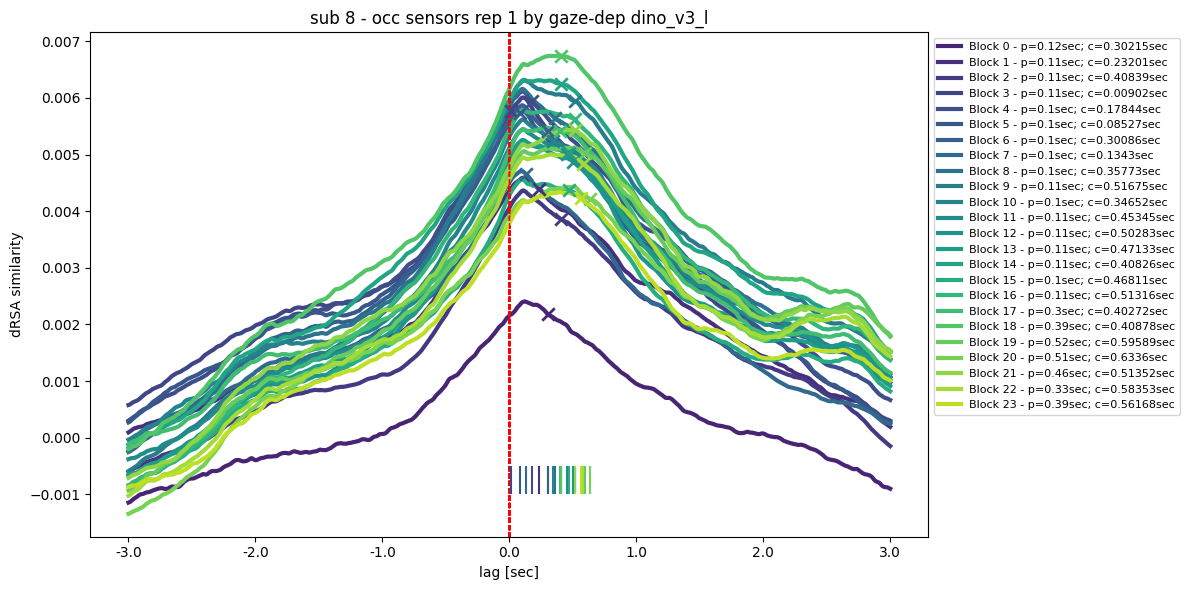

In [18]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot, get_centroid
from useful_stuff.image_processing.computational_models import get_relevant_output_layers


lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, 24))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
plt.figure(figsize=(12, 6))
for idx, l in enumerate(layers[:]):
    try:
        full_model_name = f"{cfg.model_name}_{l}"
        res_path = save_lagged_comparisons(paths, cfg.analysis_type, cfg.sub_num, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
        res = loadmat(res_path)["RSA"]
        lagplot = get_lagplot(res, cfg.max_lag)
        plt.plot(lagplot)
        plt.plot(lagplot)
        lagplots.append(lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(lagplot)
        lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)

        centroid_lag = np.round(get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=.1), 5)
        peak_val = lagplot[peak_idx]
        peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
        peaks.append(peak_lag)
        centroids.append(centroid_lag)
        if not np.isnan(centroid_lag):
            centroid_idx = centroid_lag * cfg.neu_fs + cfg.max_lag
            centroid_y = np.interp(centroid_idx, np.arange(len(lagplot)), lagplot)
            base_y = np.min(lagplot) - 0.05 * (np.max(lagplot) - np.min(lagplot))
            plt.vlines(
                centroid_idx,
                -.001,
                -.001 + 0.0005,
                color=colors[idx],
                zorder=3,
            )
            plt.scatter(
                centroid_idx,
                centroid_y,
                marker="x",
                s=80,
                linewidths=2,
                color=colors[idx],
                zorder=7,
            )
        plt.plot(lagplot, linewidth=3, label=f"Block {idx} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[idx])
        plt.ylabel("dRSA similarity")
        plt.xlabel("lag [sec]")
        plt.xticks(ticks, ticks_labels)
        plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
        

    except FileNotFoundError:
        print(f"{res_path} not found")
        pass
plt.title(f"sub {cfg.sub_num} - {cfg.sensors_group} sensors rep {cfg.repetition+1} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

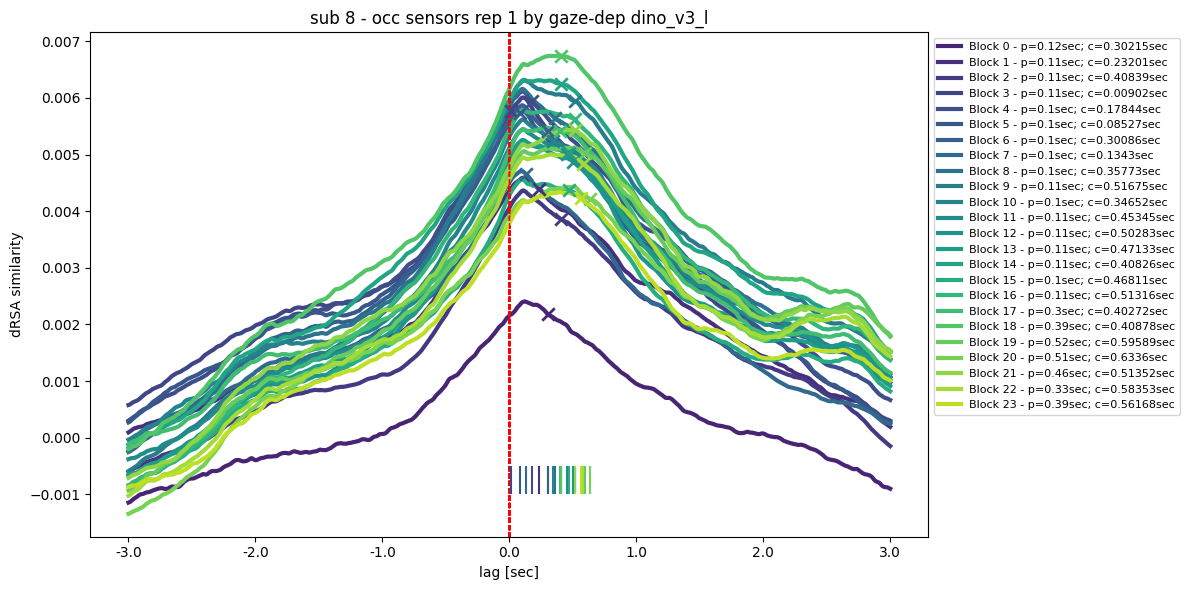

In [ ]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot, get_centroid
from useful_stuff.image_processing.computational_models import get_relevant_output_layers


lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, 24))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
plt.figure(figsize=(12, 6))
for idx, l in enumerate(layers[:]):
    try:
        full_model_name = f"{cfg.model_name}_{l}"
        res_path = save_lagged_comparisons(paths, cfg.analysis_type, cfg.sub_num, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
        res = loadmat(res_path)["RSA"]
        lagplot = get_lagplot(res, cfg.max_lag)
        plt.plot(lagplot)
        plt.plot(lagplot)
        lagplots.append(lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(lagplot)
        lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)

        centroid_lag = np.round(get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=.1), 5)
        peak_val = lagplot[peak_idx]
        peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
        peaks.append(peak_lag)
        centroids.append(centroid_lag)
        if not np.isnan(centroid_lag):
            centroid_idx = centroid_lag * cfg.neu_fs + cfg.max_lag
            centroid_y = np.interp(centroid_idx, np.arange(len(lagplot)), lagplot)
            base_y = np.min(lagplot) - 0.05 * (np.max(lagplot) - np.min(lagplot))
            plt.vlines(
                centroid_idx,
                -.001,
                -.001 + 0.0005,
                color=colors[idx],
                zorder=3,
            )
            plt.scatter(
                centroid_idx,
                centroid_y,
                marker="x",
                s=80,
                linewidths=2,
                color=colors[idx],
                zorder=7,
            )
        plt.plot(lagplot, linewidth=3, label=f"Block {idx} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[idx])
        plt.ylabel("dRSA similarity")
        plt.xlabel("lag [sec]")
        plt.xticks(ticks, ticks_labels)
        plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
        

    except FileNotFoundError:
        print(f"{res_path} not found")
        pass
plt.title(f"sub {cfg.sub_num} - {cfg.sensors_group} sensors rep {cfg.repetition+1} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

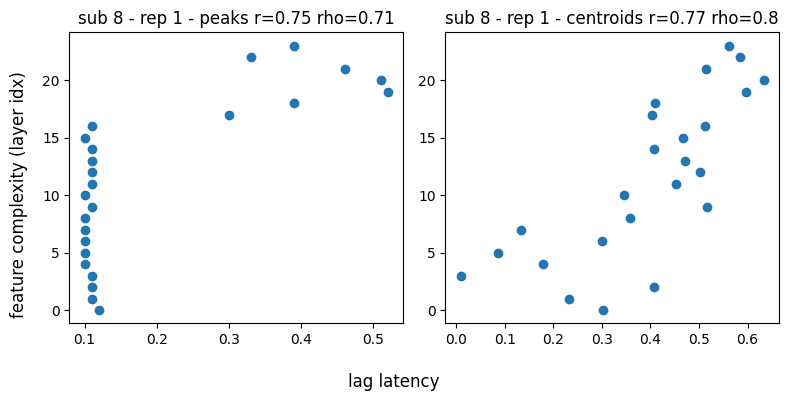

In [19]:
from useful_stuff.general_utils.utils import spearman
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"sub {cfg.sub_num} - rep {cfg.repetition+1} - peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"sub {cfg.sub_num} - rep {cfg.repetition+1} - centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

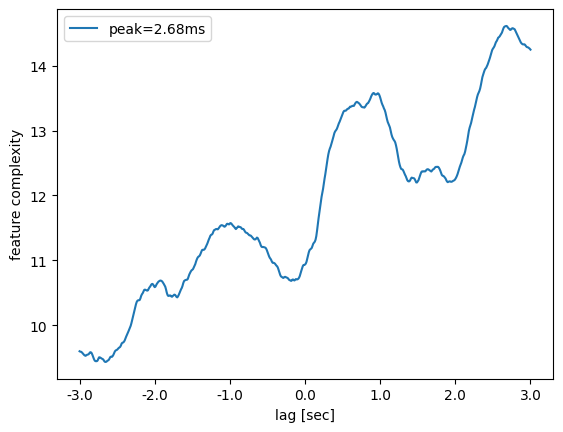

In [20]:
from useful_stuff.general_utils.utils import softmax
lps = np.stack(lagplots, axis=0)
softmax_lp = []
hardmax = []
temp = .001
for t in range(lps.shape[1]):
    softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0]))
    hardmax.append(np.argmax(lps[:,t]))
plt.xticks(ticks, ticks_labels)
plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms")
# plt.plot(hardmax)
plt.xlabel("lag [sec]")
plt.ylabel("feature complexity")
plt.legend()

# SUBJECTS AVERAGE

08:26:14 - sub=12 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=13 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=14 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=15 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=16 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=17 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=18 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=19 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=20 layer=layer.0.mlp.down_proj not found
08:26:14 - sub=12 layer=layer.1.mlp.down_proj not found
08:26:14 - sub=13 layer=layer.1.mlp.down_proj not found
08:26:14 - sub=14 layer=layer.1.mlp.down_proj not found
08:26:14 - sub=15 layer=layer.1.mlp.down_proj not found
08:26:14 - sub=16 layer=layer.1.mlp.down_proj not found
08:26:14 - sub=17 layer=layer.1.mlp.down_proj not found
08:26:14 - sub=18 layer=layer.1.mlp.down_proj not found
08:26:14 - sub=19 layer=layer.1.mlp.down_proj not found
08:26:14 - sub=20 layer=layer.1.mlp.down_proj no

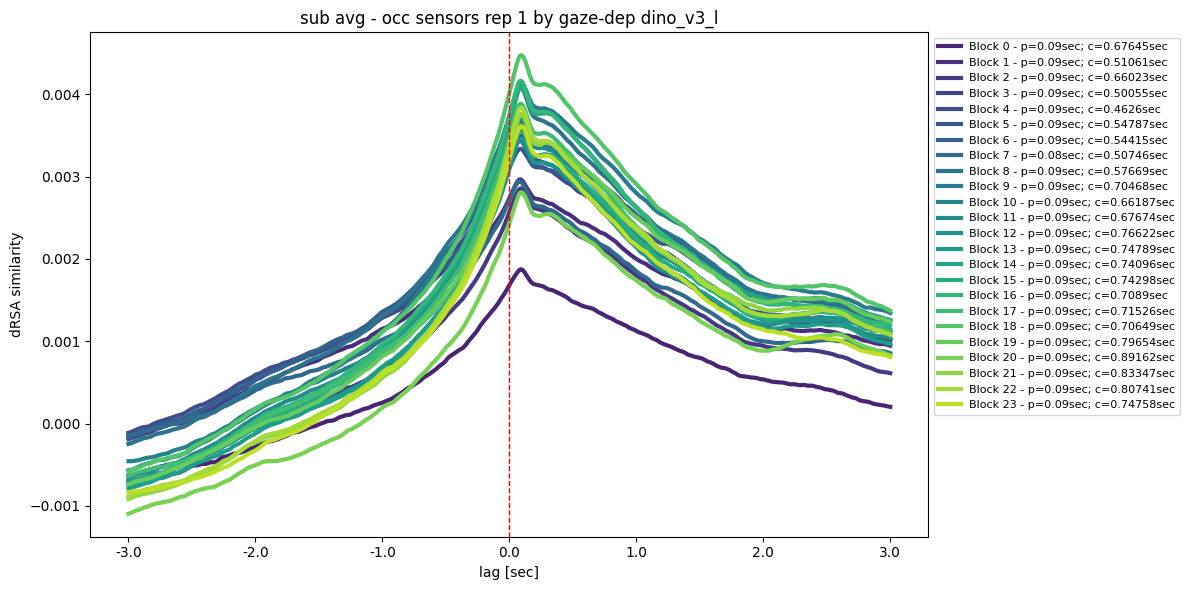

In [21]:
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
from useful_stuff.general_utils.plots import truncate_colormap
from useful_stuff.general_utils.utils import get_lagplot
from useful_stuff.image_processing.computational_models import get_relevant_output_layers

lagplots = []
# --- choose colormap ---
cmap = truncate_colormap(plt.cm.viridis)  # or "plasma", "coolwarm", etc.
colors = cmap(np.linspace(0, 1, len(layers)))
peaks = []
centroids = []
ticks = np.arange(-cfg.max_lag, cfg.max_lag + 1, cfg.tick_step)
ticks_labels = np.round(ticks / cfg.neu_fs, 2)
ticks += cfg.max_lag
plt.figure(figsize=(12, 6))
all_peaks = []
all_centroids = []
for idx, l in enumerate(layers):
        full_model_name = f"{cfg.model_name}_{l}"
        sub_counter = 0
        lagplot_sum = np.zeros(cfg.max_lag*2 +1)
        for i_sub in config["subjects"]:
            try:
                res_path = save_lagged_comparisons(paths, cfg.analysis_type, i_sub, cfg.sensors_group, cfg.repetition, full_model_name, cfg.iterations_n, cfg.len_or_lag, cfg.neu_fs, signal_metric=cfg.signal_metric, model_metric=cfg.model_metric, pseudotrials_n=cfg.pseudotrials_n, sq_side=cfg.sq_side, regress_out_gaze=cfg.regress_out_gaze)
                res = loadmat(res_path)["RSA"]    
                lagplot = get_lagplot(res, cfg.max_lag)
                sub_counter +=1
            except FileNotFoundError:
                print_wise(f"sub={i_sub} layer={l} not found")
                continue
            peak_lag = (np.argmax(lagplot) - cfg.max_lag) / cfg.neu_fs  # convert to seconds
            all_peaks.append([idx, peak_lag])
            centroid_lag = np.round(get_centroid(lagplot, cfg.max_lag, cfg.neu_fs, min_peak_percent=.5), 5)
            if not np.isnan(centroid_lag):
                all_centroids.append([idx, centroid_lag])
            lagplot_sum += lagplot
        avg_lagplot = lagplot_sum/sub_counter
        lagplots.append(avg_lagplot)
        # --- compute peak ---
        peak_idx = np.argmax(avg_lagplot)
        lags = np.arange(-cfg.max_lag, cfg.max_lag + 1)

        weights = avg_lagplot.copy()
        weights[weights < 0] = 0  # optional but recommended
        centroid = np.sum(lags * weights) / np.sum(weights)
        centroid_lag = np.round(centroid / cfg.neu_fs, 5)
        peak_val = avg_lagplot[peak_idx]
        peak_lag = (peak_idx - cfg.max_lag) / cfg.neu_fs  # convert to seconds
        peaks.append(peak_lag)
        centroids.append(centroid_lag)
        plt.plot(avg_lagplot, linewidth=3, label=f"Block {idx} - p={peak_lag}sec; c={centroid_lag}sec", color=colors[idx])

plt.ylabel("dRSA similarity")
plt.xlabel("lag [sec]")
plt.xticks(ticks, ticks_labels)
plt.axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
        

plt.title(f"sub avg - {cfg.sensors_group} sensors rep {cfg.repetition+1} by gaze-dep {cfg.model_name}")#{cfg.sensors_group} sensors - regr out")
plt.legend(fontsize=8, loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()

In [13]:
print(all_peaks)

[[0, np.float64(0.3)], [0, np.float64(0.1)], [0, np.float64(0.09)], [0, np.float64(0.1)], [0, np.float64(0.06)], [0, np.float64(-0.11)], [0, np.float64(0.15)], [0, np.float64(0.08)], [0, np.float64(0.08)], [0, np.float64(0.1)], [1, np.float64(0.36)], [1, np.float64(0.09)], [1, np.float64(0.09)], [1, np.float64(0.09)], [1, np.float64(0.07)], [1, np.float64(0.09)], [1, np.float64(0.1)], [1, np.float64(0.07)], [1, np.float64(0.09)], [1, np.float64(0.09)], [2, np.float64(0.36)], [2, np.float64(0.1)], [2, np.float64(0.1)], [2, np.float64(0.09)], [2, np.float64(0.08)], [2, np.float64(0.1)], [2, np.float64(0.09)], [2, np.float64(0.08)], [2, np.float64(0.08)], [2, np.float64(0.1)], [3, np.float64(0.33)], [3, np.float64(0.1)], [3, np.float64(0.09)], [3, np.float64(0.09)], [3, np.float64(0.08)], [3, np.float64(0.08)], [3, np.float64(0.1)], [3, np.float64(0.08)], [3, np.float64(0.09)], [3, np.float64(0.09)], [4, np.float64(0.3)], [4, np.float64(0.1)], [4, np.float64(0.09)], [4, np.float64(0.09)],

-0.08570741949983524
0.008167518069993688


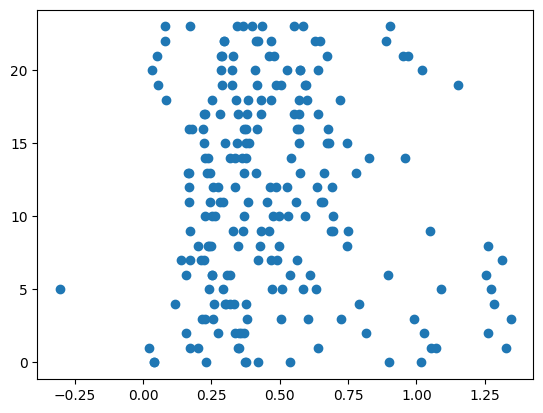

In [22]:
all_centroids = np.stack(all_centroids)
plt.scatter(all_centroids[:,1], all_centroids[:,0])
print(np.corrcoef(all_centroids[:,1], all_centroids[:,0])[0,1])
print(spearman(all_centroids[:,1], all_centroids[:,0]))

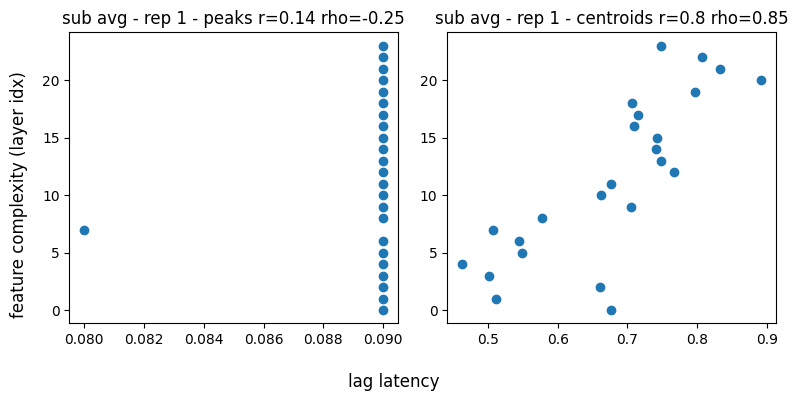

In [23]:
from useful_stuff.general_utils.utils import spearman
fig, ax = plt.subplots(1,2, figsize=(8, 4))
ax[0].scatter(np.array(peaks), np.arange(len(peaks)))
rho = np.round(spearman(np.arange(len(peaks)), np.array(peaks)),2)
r = round(np.corrcoef(np.arange(len(peaks)), np.array(peaks))[0,1],2)
ax[0].set_title(f"sub avg - rep {cfg.repetition+1} - peaks r={r} rho={rho}")
ax[1].scatter(centroids, np.arange(len(centroids)));
rho = np.round(spearman(np.arange(len(peaks)), np.array(centroids)), 2)
r = round(np.corrcoef(np.arange(len(centroids)), np.array(centroids))[0,1],2)
ax[1].set_title(f"sub avg - rep {cfg.repetition+1} - centroids r={r} rho={rho}")
fig.supxlabel("lag latency")
fig.supylabel("feature complexity (layer idx)")
fig.tight_layout()

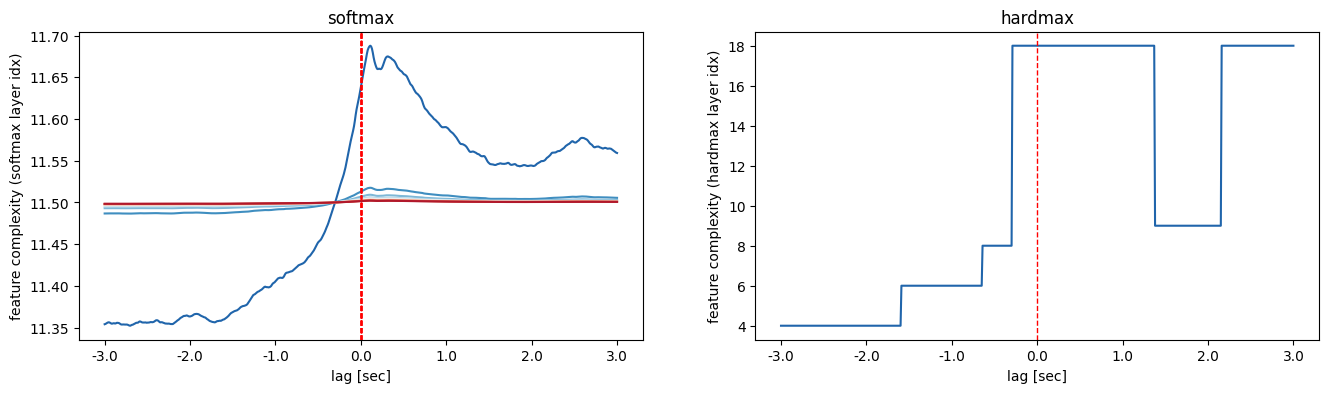

In [24]:
from useful_stuff.general_utils.utils import softmax
lps = np.stack(lagplots, axis=0)
softmax_lp = []
hardmax_lp = []

temp = .001
temp_range = np.arange(0.01, 1, 0.1)
cmap = truncate_colormap(plt.cm.RdBu)
colors = cmap(np.linspace(0, 1, len(temp_range)))[::-1]
fig, ax = plt.subplots(1,2, figsize=(16,4))

for idx, temp in enumerate(temp_range):
    softmax_lp = []
    for t in range(lps.shape[1]):
        softmax_lp.append(softmax(lps[:,t], T=temp)@np.arange(lps.shape[0]))
        if temp==temp_range[-1]:
            hardmax_lp.append(np.argmax(lps[:,t]))
    # plt.plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax[0].plot(softmax_lp, label=f"peak={(np.argmax(softmax_lp)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[idx])
    ax[0].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
    ax[0].set_xticks(ticks, ticks_labels)
    ax[0].set_xlabel("lag [sec]")
    ax[0].set_ylabel("feature complexity (softmax layer idx)")
    ax[0].set_title("softmax")
ax[1].plot(hardmax_lp, label=f"peak={(np.argmax(hardmax)-cfg.max_lag)/cfg.neu_fs}ms", color=colors[0])
ax[1].axvline(cfg.max_lag, color="r", linestyle="--", linewidth=1)
ax[1].set_xticks(ticks, ticks_labels)
ax[1].set_xlabel("lag [sec]")
ax[1].set_ylabel("feature complexity (hardmax layer idx)")
ax[1].set_title("hardmax");